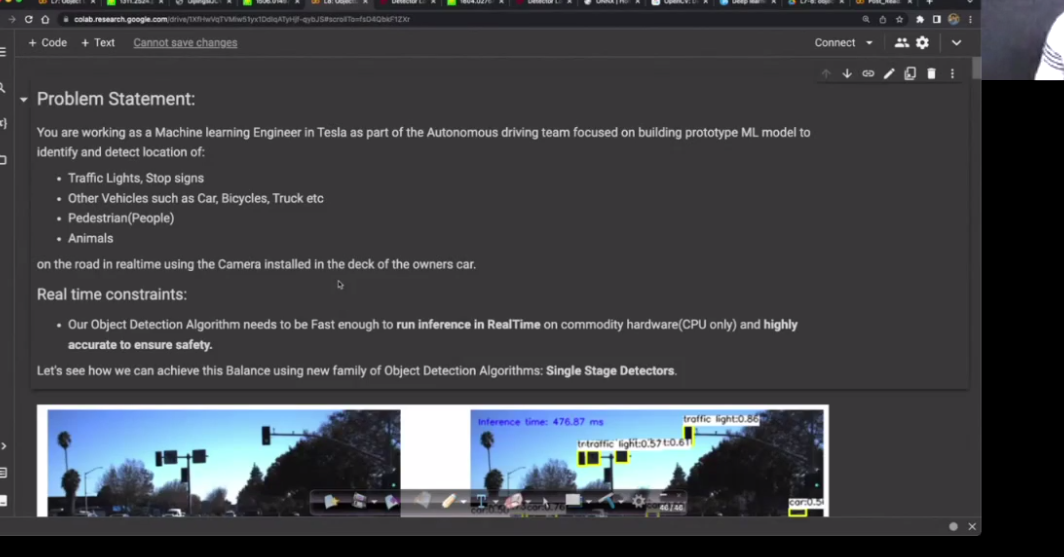

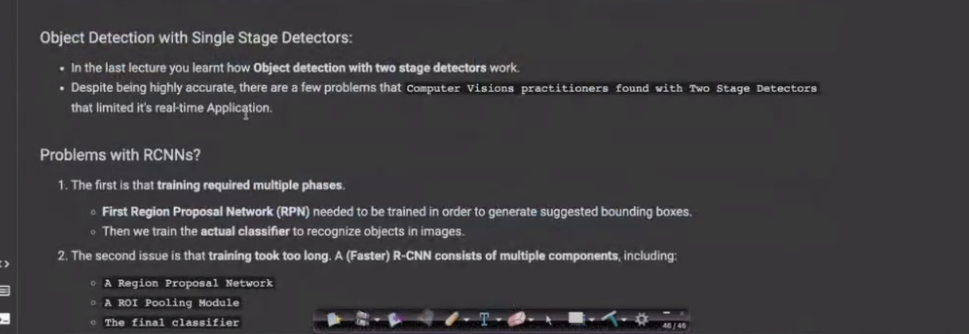

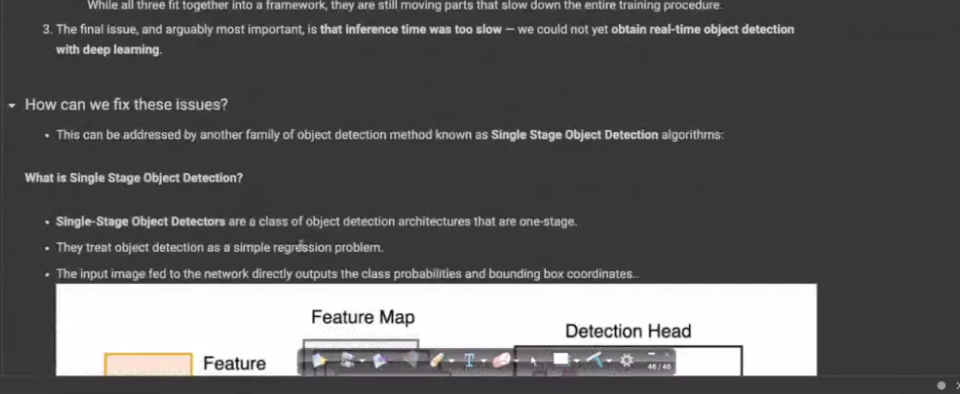

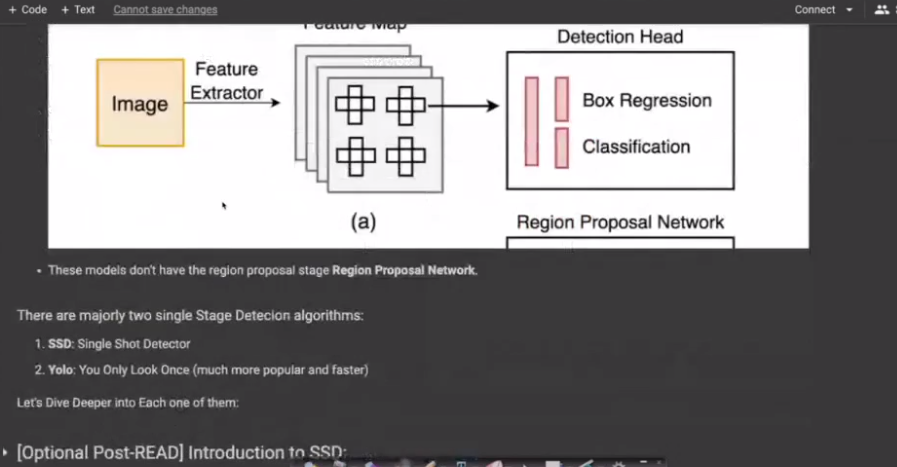

research paper = https://arxiv.org/pdf/1512.02325.pdf

## Single Shot Detector (SSD) in Computer Vision

Single Shot Detector (SSD) is a popular object detection algorithm that belongs to the family of single-stage detectors. Unlike two-stage detectors like Faster R-CNN (which first propose regions and then classify them), SSD performs object localization and classification in a single forward pass of a convolutional neural network (CNN).

This makes SSD significantly faster, making it suitable for real-time applications, while still maintaining competitive accuracy.


### Key Components of SSD

SSD's architecture relies on several key components:

1.  **Multi-scale Feature Maps for Detection**: SSD uses multiple feature maps from different layers of a CNN backbone (e.g., VGG, ResNet). This allows it to detect objects of various scales. Lower-level feature maps (closer to the input) capture fine-grained details for small objects, while higher-level feature maps (closer to the output) capture larger objects with more semantic information.

2.  **Anchor Boxes (Default Boxes)**: At each location in each feature map, SSD pre-defines a fixed set of default bounding boxes (or anchor boxes) with different aspect ratios and scales. These anchor boxes are designed to cover a wide range of possible object shapes and sizes.

3.  **Convolutional Predictors**: For each default box, a small convolutional filter is applied to predict two things:
    *   **Class Scores**: The probability of an object belonging to each predefined class (plus a background class).
    *   **Box Offsets**: Adjustments (offsets) to the default box's coordinates to better match the ground truth object.

4.  **Non-Maximum Suppression (NMS)**: After generating a large number of predictions, NMS is used to filter out redundant detections. It selects the bounding box with the highest confidence score for a particular object and suppresses (removes) other overlapping boxes that predict the same object.


### How SSD Works (High-Level Overview)

1.  **Input Image**: An image is fed into a pre-trained CNN backbone (e.g., VGG-16, ResNet).
2.  **Feature Extraction**: The CNN extracts feature maps at various scales (different layers).
3.  **Anchor Box Generation**: For each cell in these multi-scale feature maps, a set of pre-defined anchor boxes (default boxes) is generated.
4.  **Predictions**: Small convolutional filters are applied to each anchor box to predict:
    *   The object class scores (e.g., car, pedestrian, background).
    *   Bounding box offsets (adjustments to the anchor box's coordinates).
5.  **Decoding and NMS**: The predicted offsets are applied to the anchor boxes to generate actual bounding box proposals. These proposals are then filtered using Non-Maximum Suppression (NMS) to remove duplicates and keep only the most confident and representative detections.
6.  **Output**: The final output is a list of detected objects, each with its predicted class, confidence score, and refined bounding box coordinates.


### Advantages and Disadvantages

**Advantages:**
*   **Speed**: Faster than two-stage detectors due to its single-shot nature.
*   **Accuracy**: Achieves competitive accuracy compared to other state-of-the-art models.
*   **Multi-scale Detection**: Effective at detecting objects of various sizes thanks to multi-scale feature maps.

**Disadvantages:**
*   **Small Object Detection**: Can sometimes struggle with very small objects, especially when compared to specialized two-stage detectors designed for fine details.
*   **Anchor Box Sensitivity**: Performance can be sensitive to the design and configuration of anchor boxes.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape, Input
from tensorflow.keras.models import Model

# This is a highly simplified conceptual example to illustrate SSD's structure.
# An actual SSD implementation involves much more complex anchor box generation,
# loss functions, and multi-scale prediction heads.

def create_simple_ssd_model(input_shape=(300, 300, 3), num_classes=2):
    # Simplified backbone (e.g., a few VGG-like layers)
    input_tensor = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_tensor)
    x = MaxPooling2D((2, 2), strides=(2, 2), padding='same')(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), padding='same')(x)

    # Example of a feature map for prediction
    # In a real SSD, you'd have multiple feature maps at different resolutions
    feature_map_1 = Conv2D(256, (3, 3), activation='relu', padding='same')(x)

    # Prediction head for feature_map_1
    # Each anchor box predicts (num_classes + 4) outputs (class scores + bbox offsets)
    num_anchors_per_location = 4 # Simplified, could be more in real SSD

    # Class predictions (num_classes scores for each anchor box)
    classes_pred_1 = Conv2D(num_anchors_per_location * num_classes, (3, 3), padding='same')(feature_map_1)
    classes_pred_1 = Reshape((-1, num_classes), name='classes_pred_1')(classes_pred_1)

    # Bounding box predictions (4 offsets for each anchor box)
    bbox_pred_1 = Conv2D(num_anchors_per_location * 4, (3, 3), padding='same')(feature_map_1)
    bbox_pred_1 = Reshape((-1, 4), name='bbox_pred_1')(bbox_pred_1)

    # In a real SSD, you'd concatenate predictions from multiple feature maps
    # and apply activation functions (softmax for classes, linear for bbox)

    model = Model(inputs=input_tensor, outputs=[classes_pred_1, bbox_pred_1])

    return model

# Create a dummy model instance
ssd_model = create_simple_ssd_model()

# Print the model summary to see the simplified structure
print(ssd_model.summary())

print("\nThis is a conceptual model. A full SSD implementation involves:")
print("- Multiple prediction heads on different feature map scales.")
print("- More sophisticated anchor box generation (scales, aspect ratios).")
print("- A custom loss function combining classification and localization losses.")
print("- Non-Maximum Suppression (NMS) applied to the final predictions.")


**YOLO algorithm**

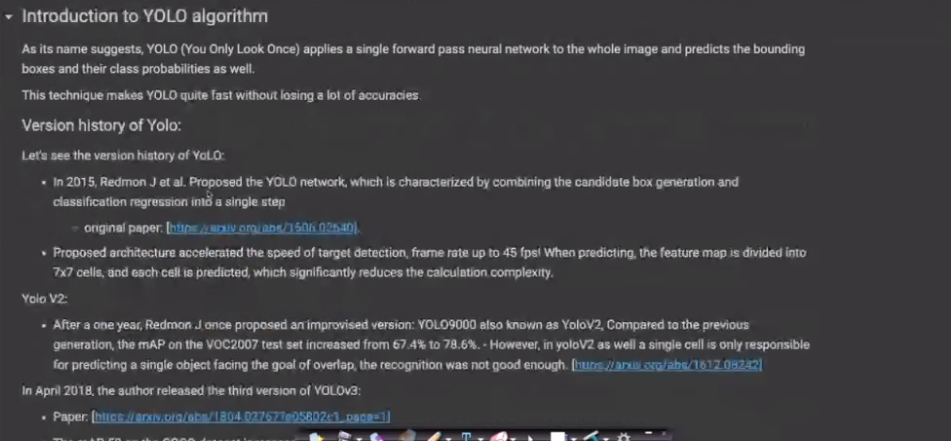

## YOLO (You Only Look Once) Algorithm

YOLO (You Only Look Once) is another highly influential and widely used real-time object detection system. Similar to SSD, it is a single-stage detector, meaning it predicts bounding boxes and class probabilities simultaneously in a single pass of a neural network. This 'look once' approach makes it incredibly fast, often suitable for real-time applications, while still achieving high accuracy.

Traditionally, object detection systems would separate the problem into two parts: first, identifying potential bounding box regions, and then classifying those regions. YOLO reframes object detection as a single regression problem, directly going from image pixels to bounding box coordinates and class probabilities.

### Key Concepts of YOLO

1.  **Grid Cell Division**: YOLO divides the input image into an `S x S` grid. If the center of an object falls into a particular grid cell, that grid cell is responsible for detecting that object.

2.  **Bounding Box Predictions**: Each grid cell predicts `B` bounding boxes and confidence scores for those boxes. A confidence score reflects how confident the model is that the box contains an object and also the accuracy of the predicted box.

3.  **Class Probability Predictions**: Each grid cell also predicts `C` conditional class probabilities ($P(	ext{Class}_i | 	ext{Object})$). These probabilities are conditioned on the grid cell containing an object. Only one set of class probabilities is predicted per grid cell, regardless of the number of bounding boxes `B`.

4.  **Final Predictions**: For each bounding box predicted by a grid cell, YOLO calculates a class-specific confidence score. This score is calculated as:
    $P(	ext{Class}_i | 	ext{Object}) * P(	ext{Object}) * 	ext{IOU}^{	ext{truth}}_{	ext{pred}} = P(	ext{Class}_i) * 	ext{IOU}^{	ext{truth}}_{	ext{pred}}$
    This score encodes both the probability of that class appearing in the box and how well the predicted box fits the object.

5.  **Non-Max Suppression (NMS)**: Similar to SSD, NMS is applied to remove duplicate detections and keep only the most confident and accurate bounding boxes for each object.

### How YOLO Works (High-Level Overview)

1.  **Input Image**: An input image is resized to a fixed size (e.g., 448x448 for original YOLO) and fed into a single convolutional network.

2.  **Feature Extraction**: The convolutional layers extract features from the image.

3.  **Unified Detection Head**: Unlike multi-scale feature maps in SSD, original YOLO uses a single final convolutional layer to make predictions directly. This layer outputs a tensor that encodes:
    *   Bounding box coordinates (x, y, width, height) for each `B` bounding box per grid cell.
    *   Confidence score for each `B` bounding box per grid cell.
    *   Class probabilities for `C` classes per grid cell.

4.  **Reshaping and Decoding**: The output tensor is reshaped and interpreted to obtain the actual bounding boxes, confidence scores, and class probabilities.

5.  **Filtering and NMS**: Low-confidence predictions are filtered out, and Non-Max Suppression is applied to eliminate redundant bounding boxes, yielding the final object detections.

### Advantages and Disadvantages of YOLO

**Advantages:**
*   **Extremely Fast**: Its single-pass architecture makes it one of the fastest object detection algorithms, crucial for real-time applications.
*   **Global Context**: YOLO sees the entire image during training and testing, allowing it to implicitly encode contextual information about classes and their appearance, which helps reduce false positives.
*   **Generalizability**: It learns generalizable representations of objects, making it less prone to errors on new, unseen domains.

**Disadvantages:**
*   **Accuracy with Small Objects**: The original YOLO struggles with detecting small objects that appear in groups (e.g., a flock of birds) because each grid cell can only predict a limited number of bounding boxes and has only one set of class probabilities.
*   **Poor Localization Accuracy**: Compared to two-stage detectors, YOLO can sometimes have less precise bounding box localization.
*   **Aspect Ratio Limitations**: The fixed number of bounding boxes and their predetermined aspect ratios can limit its ability to detect objects with unusual aspect ratios effectively.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape, Input
from tensorflow.keras.models import Model

# This is a highly simplified conceptual example to illustrate the core idea of YOLO.
# Modern YOLO versions (like YOLOv3, v4, v5, v7, v8) are much more complex,
# incorporating anchor boxes, FPN, and more sophisticated backbones and loss functions.

def create_simple_yolo_model(input_shape=(448, 448, 3), S=7, B=2, num_classes=20):
    # S: Grid size (S x S)
    # B: Number of bounding boxes per grid cell
    # num_classes: Number of object classes

    input_tensor = Input(shape=input_shape)

    # Simplified backbone (e.g., a few convolutional and max-pooling layers)
    x = Conv2D(64, (7, 7), strides=(2, 2), activation='relu', padding='same')(input_tensor)
    x = MaxPooling2D((2, 2), strides=(2, 2), padding='same')(x)

    x = Conv2D(192, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), padding='same')(x)

    x = Conv2D(128, (1, 1), activation='relu', padding='same')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(256, (1, 1), activation='relu', padding='same')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), padding='same')(x)

    # ... more convolutional layers ...

    # Final layers for prediction
    # Each grid cell predicts: B bounding boxes (x, y, w, h, confidence) + C class probabilities
    # Output tensor size: S x S x (B * 5 + C)

    # For each bounding box: 4 coordinates + 1 confidence score
    # For each grid cell: C class probabilities

    # Output dimensions for (x, y, w, h, confidence) per box, and class probabilities per grid cell
    output_dim = (B * 5) + num_classes

    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)

    # Output layer: S*S cells, each with (B*5 + C) predictions
    output = Dense(S * S * output_dim, activation='linear')(x)
    output = Reshape((S, S, output_dim), name='yolo_output')(output)

    model = Model(inputs=input_tensor, outputs=output)

    return model

# Create a dummy YOLO model instance
yolo_model = create_simple_yolo_model()

# Print the model summary to see the simplified structure
print(yolo_model.summary())

print("\nThis is a conceptual model. A full YOLO implementation involves:")
print("- A more extensive convolutional backbone (e.g., Darknet).")
print("- Specialized loss functions (e.g., sum-squared error on coordinates, classification, and confidence).")
print("- Handling of multiple scales and anchor boxes (in later versions).")
print("- Post-processing steps like Non-Maximum Suppression (NMS).")

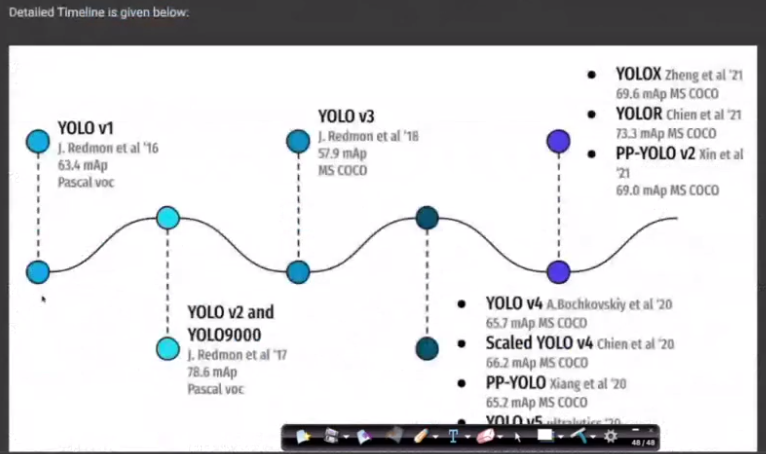

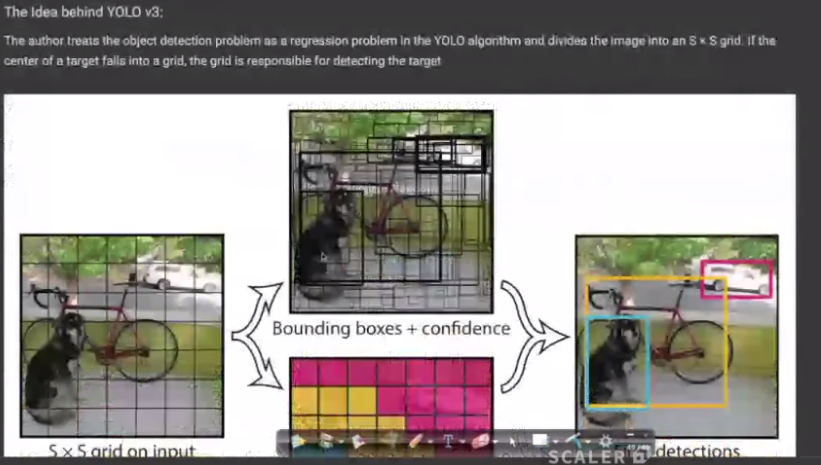

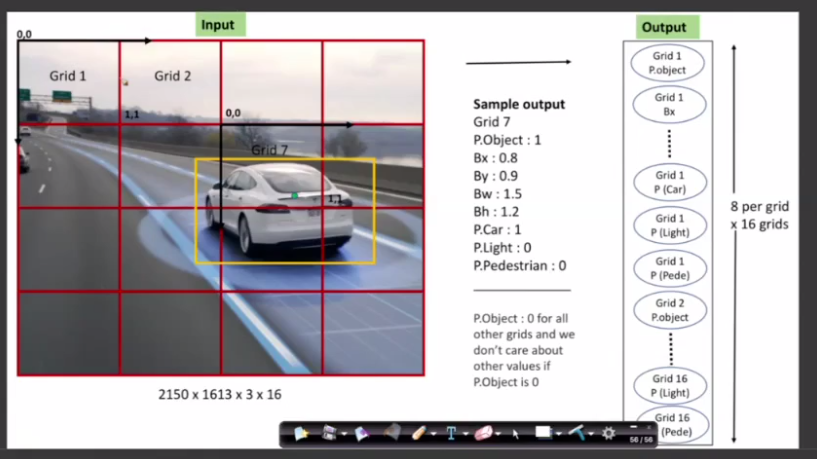

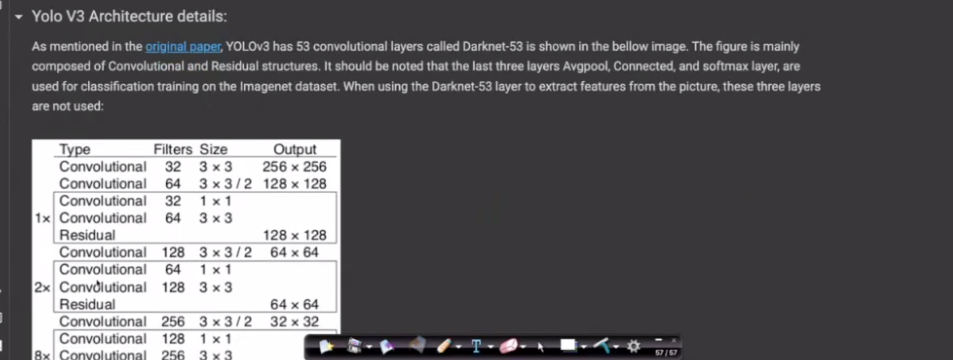

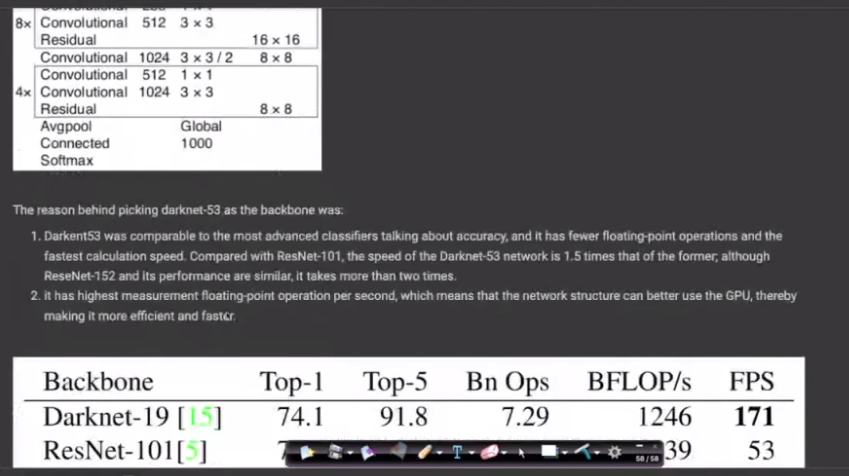

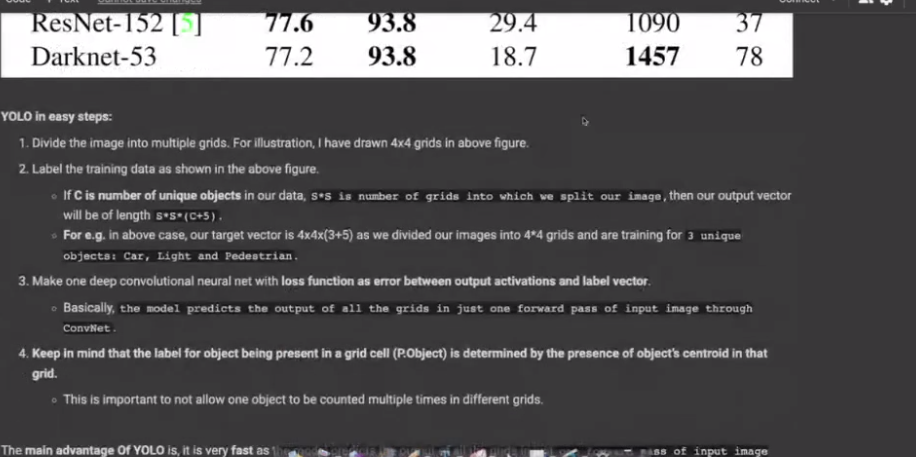

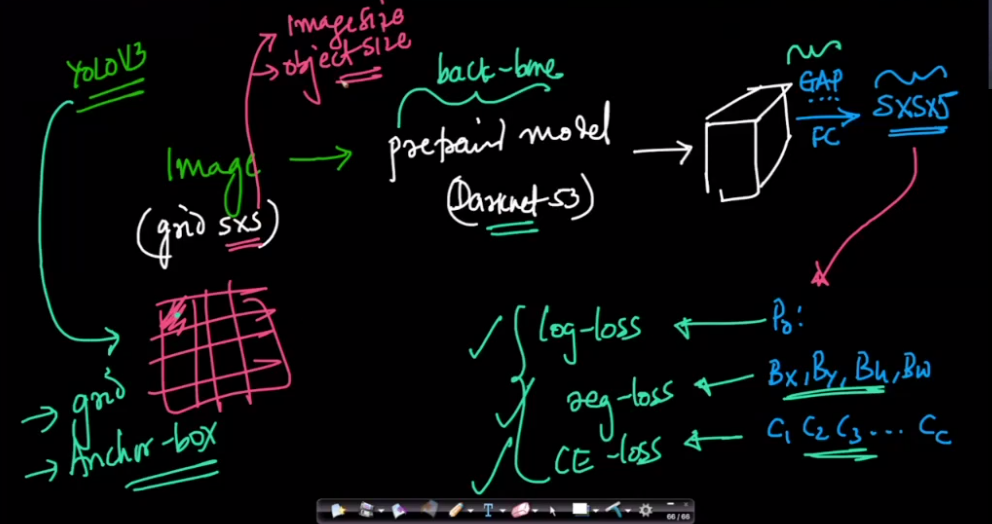